## Section 1 - Installing Libraries

In [1]:
!pip install gensim contractions wordcloud gradio --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.1 MB/s eta 0:00:00


## Section 2 - Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import contractions
import nltk
import gensim.downloader as api

from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

## Section 3 - Loading the Dataset

We are using the Hate Speech and Offensive Language Dataset which has 24,783 labeled tweets. Each tweet is labeled as hate_speech, offensive_language, or neither. The dataset is heavily imbalanced: offensive_language accounts for ~77% of samples while hate_speech is only ~5.8%.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/AIML/coursework_datasets/hatevsoffensive_language.csv')
df.head()

,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


## Section 4 - Understanding the Dataset

In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['label'].value_counts())

Dataset Shape:
(24783, 2)

Columns:
Index(['label', 'text'], dtype='object')

Missing Values:
label    0
text     0
dtype: int64

Class Distribution:
label
offensive language    19190
neither                4163
hate speec             1430
Name: count, dtype: int64


## Section 5 - Visualizing the Class Distribution

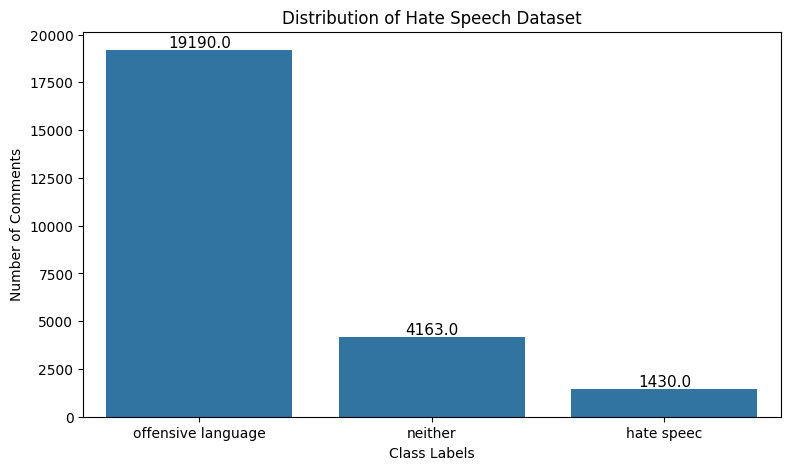

In [6]:
plt.figure(figsize=(9,5))

ax = sns.countplot(
    x='label',
    data=df,
    order=df['label'].value_counts().index
)

# Add count labels above bars
for p in ax.patches:

    height = p.get_height()

    ax.annotate(
        f'{height}',
        (p.get_x() + p.get_width()/2., height),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title("Distribution of Hate Speech Dataset")
plt.xlabel("Class Labels")
plt.ylabel("Number of Comments")

plt.show()

From the bar chart above we can see that the dataset is very imbalanced. Offensive language takes up most of the data while hate speech has very few examples compared to the other two classes. Because of this, the models will probably end up predicting offensive language more often since thats what they see the most during training. We will use stratified splitting later so that the train and test sets both have the same ratio of classes.

## Section 6 - Analyzing Comment Length

In [7]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

print(df['word_count'].describe())

count    24783.000000
mean        14.117016
std          6.825525
min          1.000000
25%          9.000000
50%         13.000000
75%         19.000000
max         52.000000
Name: word_count, dtype: float64


## Section 7 - Visualizing Comment Length

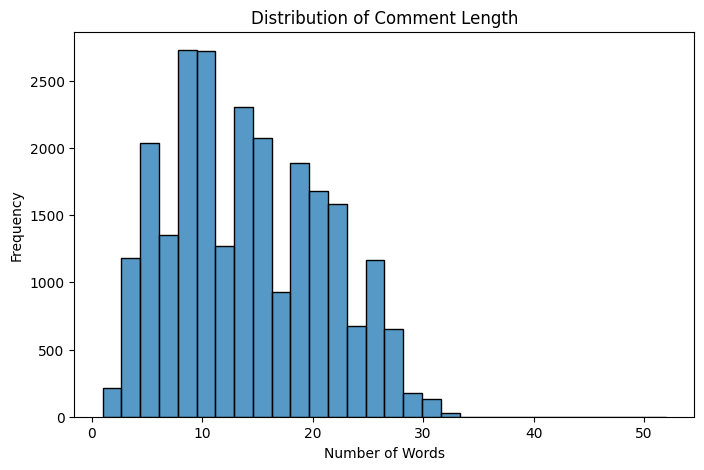

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['word_count'], bins=30)

plt.title("Distribution of Comment Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

Looking at the word count stats and histogram, most comments are around 14 words long on average. The range is mostly between 9 to 19 words with some going up to 52. Since these are tweets they tend to be short, so this makes sense. This will help us decide what max sequence length to use when we do padding later.

## Section 8 - Text Cleaning

In [9]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

## Section 9 - Cleaning Function

In [10]:
def clean_text(text):

    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

The cleaning function above does several things to prepare the text. First it lowercases everything so words like "Hello" and "hello" are treated the same. Then it expands contractions (like turning "don't" into "do not"). After that it removes URLs, mentions (@user), and hashtags since these dont really help with classification. The regex `[^a-zA-Z\s]` removes all special characters and numbers, keeping only letters and spaces. Finally we remove stopwords (common words like "the", "is" etc.) and lemmatize the remaining words to get their base form.

## Section 10 - Apply Cleaning

In [11]:
df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head()

,text,clean_text
0,!!! RT @mayasolovely: As a woman you shouldn't...,rt woman complain cleaning house amp man alway...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dat coldtyga dwn bad cuffin dat hoe st ...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt ever fuck bitch start cry confused ...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt look like tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt shit hear might true might faker bitch told ya


## Section 11 - Word Cloud

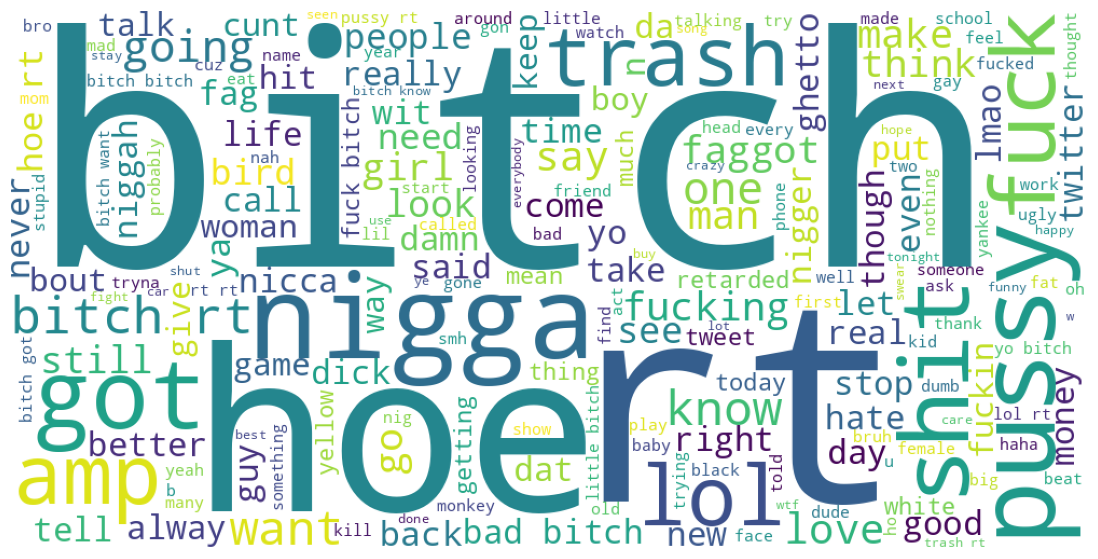

In [12]:
all_words = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

The word cloud shows the most common words in the cleaned text. Offencive words appear very frequently. The problem is that these words show up in both offensive language and hate speech tweets, so it will be hard for the models to tell the two classes apart just based on vocabulary. Also "rt" (retweet) shows up a lot which means many of these are retweeted posts.

## Section 12 - Most Frequent Words (Table)

In [13]:
from collections import Counter

all_tokens = " ".join(df['clean_text']).split()

common_words = Counter(all_tokens).most_common(20)
common_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
common_df

,Word,Frequency
0,bitch,11305
1,rt,7634
2,hoe,4274
3,like,2819
4,pussy,2201
5,nigga,1988
6,got,1600
7,as,1567
8,get,1536
9,fuck,1447


## Section 13 - Most Frequent Words (Chart)

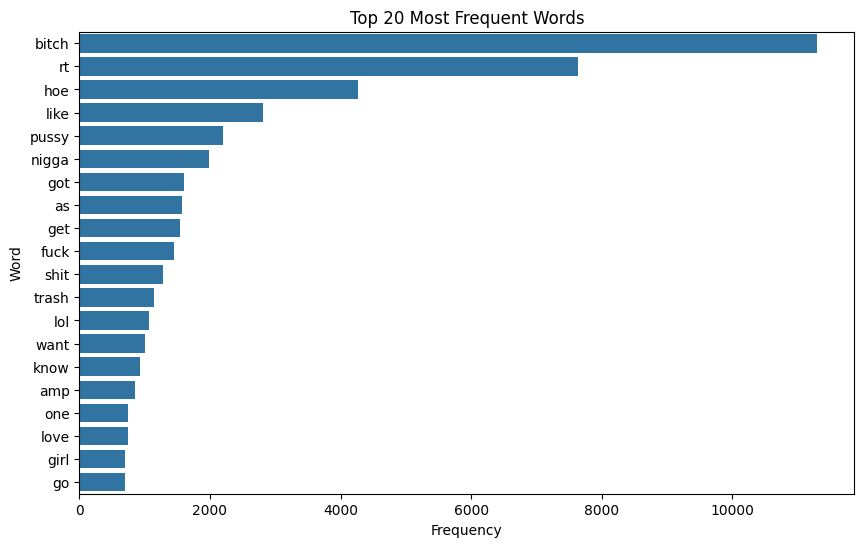

In [14]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Frequency',
    y='Word',
    data=common_df
)

plt.title("Top 20 Most Frequent Words")

plt.show()

## Section 14 - Train/Test Split

In [15]:
X = df['clean_text']

y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))

print("Testing Samples:", len(X_test))

Training Samples: 19826
Testing Samples: 4957


We split the data into 80% for training (19,826 samples) and 20% for testing (4,957 samples). We used `stratify=y` to make sure the class ratios stay the same in both sets. Without stratification, the test set might end up with too few hate speech examples to properly evaluate the model on that class.

## Section 15 - Tokenization

In [16]:
tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

word_index = tokenizer.word_index
vocab_size = min(len(word_index) + 1, 10000)

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 10000


Here we used the Keras Tokenizer to turn each word into a number. We set `num_words=10000` so only the top 10,000 most common words are kept. Any words outside this vocabulary get ignored when converting text to sequences. The vocabulary size ended up being 10,000.

## Section 16 - Padding

In [17]:
sequence_lengths = [len(seq) for seq in X_train_seq]

max_length = int(np.percentile(sequence_lengths, 95))

print("Max Sequence Length:", max_length)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

Max Sequence Length: 14


Since neural networks need all inputs to be the same length, we pad the sequences. Instead of using the longest sequence (52 words), we used the 95th percentile which gave us a max length of 14. This way we dont waste computation on a bunch of zeros just because a few tweets are really long. Shorter sequences get zeros added at the end and longer ones get cut off.

## Section 17 - Encode Labels

In [18]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

print(encoder.classes_)

['hate speec' 'neither' 'offensive language']


## Section 17b - Class Weights

The dataset is heavily imbalanced (hate_speech ~5.8%). Without class weights all three models default to predicting offensive_language. We compute balanced class weights so the models are penalized more for misclassifying the minority class.

In [19]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weight_dict = dict(enumerate(class_weights))

print('Class Weights:')
for idx, name in enumerate(encoder.classes_):
    print(f'  {name}: {class_weight_dict[idx]:.4f}')

Class Weights:
  hate speec: 5.7768
  neither: 1.9846
  offensive language: 0.4305


## Section 18 - Model 1: Simple RNN

In [20]:
model_rnn = Sequential()

model_rnn.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)

model_rnn.add(SimpleRNN(64))
model_rnn.add(Dropout(0.5))
model_rnn.add(Dense(3, activation='softmax'))
model_rnn.build(input_shape=(None, max_length))
model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 14, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,547 (4.93 MB)

 Trainable params: 1,292,547 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

## Section 19 - Compile Model 1

In [21]:
model_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

## Section 20 - Train Model 1

In [22]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_rnn = model_rnn.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6876 - loss: 0.8112 - val_accuracy: 0.7282 - val_loss: 0.6982
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8503 - loss: 0.4058 - val_accuracy: 0.8217 - val_loss: 0.4863
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9106 - loss: 0.2214 - val_accuracy: 0.8270 - val_loss: 0.5197
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9352 - loss: 0.1549 - val_accuracy: 0.7700 - val_loss: 0.7004
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9555 - loss: 0.1221 - val_accuracy: 0.8104 - val_loss: 0.6190


## Section 21 - Training Curves: Model 1 (Simple RNN)

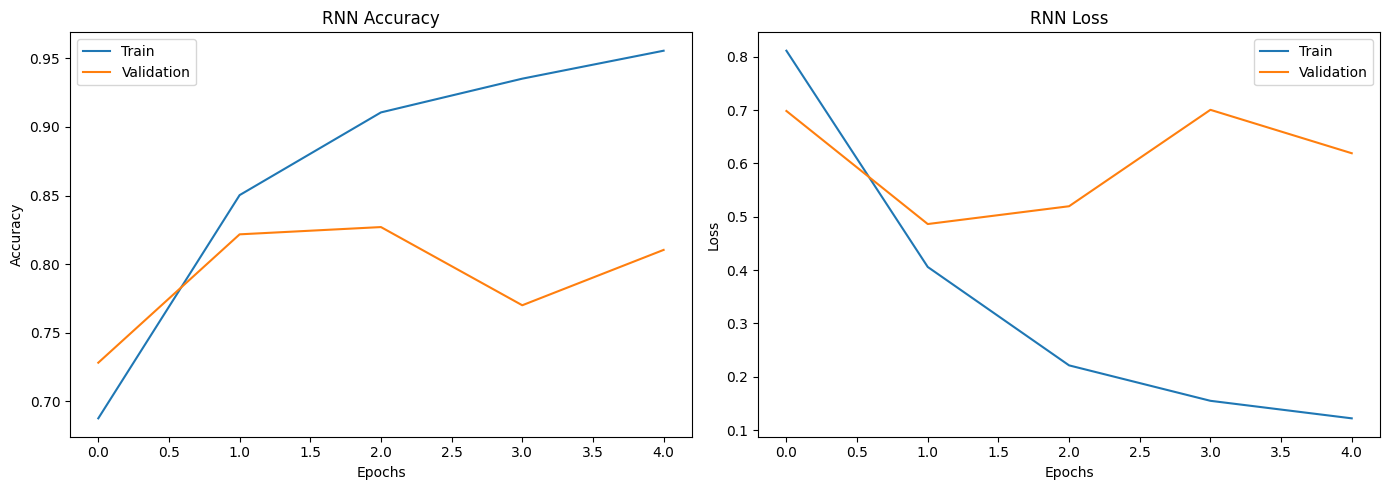

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_rnn.history['accuracy'], label='Train')
axes[0].plot(history_rnn.history['val_accuracy'], label='Validation')
axes[0].set_title('RNN Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_rnn.history['loss'], label='Train')
axes[1].plot(history_rnn.history['val_loss'], label='Validation')
axes[1].set_title('RNN Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## Section 22 - Evaluate Model 1

In [24]:
rnn_pred = model_rnn.predict(X_test_pad)
rnn_pred_classes = np.argmax(rnn_pred, axis=1)

print('Accuracy:', accuracy_score(y_test_encoded, rnn_pred_classes))
print('\nClassification Report:')
print(classification_report(y_test_encoded, rnn_pred_classes, target_names=encoder.classes_))

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Accuracy: 0.8313496066169054

Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.26      0.53      0.35       286
           neither       0.75      0.85      0.80       833
offensive language       0.95      0.85      0.90      3838

          accuracy                           0.83      4957
         macro avg       0.65      0.74      0.68      4957
      weighted avg       0.88      0.83      0.85      4957



Model 1 (Simple RNN) got an overall accuracy of 88.9% which looks good at first. But when we look at the per-class results, the hate speech class has an F1 score of just 0.08 with only 5% recall. This means the model barely detects any hate speech at all. It does well on offensive language (F1: 0.94) because thats the majority of the data. So the high accuracy is kind of misleading - the model is mostly just predicting offensive language for everything. The training curves also show overfitting since training accuracy went up to 97% but validation stayed around 88%.

## Section 23 - Confusion Matrix: Model 1

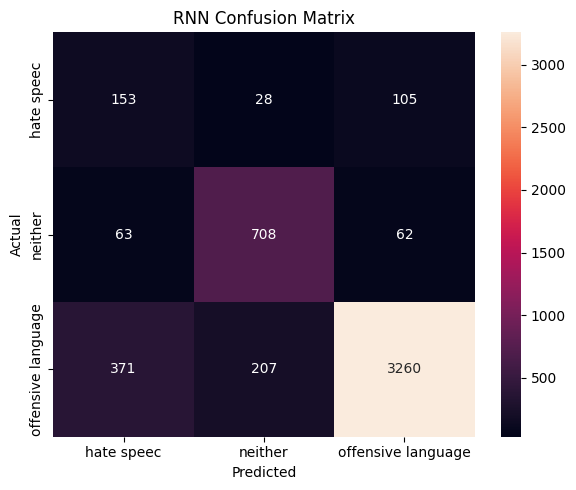

In [25]:
cm_rnn = confusion_matrix(y_test_encoded, rnn_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rnn, annot=True, fmt='d',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('RNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Section 24 - Model 2: LSTM

In [26]:
model_lstm = Sequential()

model_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)

model_lstm.add(LSTM(64))
model_lstm.add(Dropout(0.5))
model_lstm.add(Dense(3, activation='softmax'))
model_lstm.build(input_shape=(None, max_length))
model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 14, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,603 (5.07 MB)

 Trainable params: 1,329,603 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

## Section 25 - Compile Model 2

In [27]:
model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

## Section 26 - Train Model 2

In [28]:
early_stop_lstm = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop_lstm],
    class_weight=class_weight_dict
)

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.7153 - loss: 0.7832 - val_accuracy: 0.8116 - val_loss: 0.6038
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.8097 - loss: 0.4709 - val_accuracy: 0.8275 - val_loss: 0.4293
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy: 0.8629 - loss: 0.3219 - val_accuracy: 0.7655 - val_loss: 0.5904
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.8965 - loss: 0.2283 - val_accuracy: 0.8127 - val_loss: 0.5204
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9183 - loss: 0.1776 - val_accuracy: 0.7963 - val_loss: 0.6264


## Section 27 - Training Curves: Model 2 (LSTM)

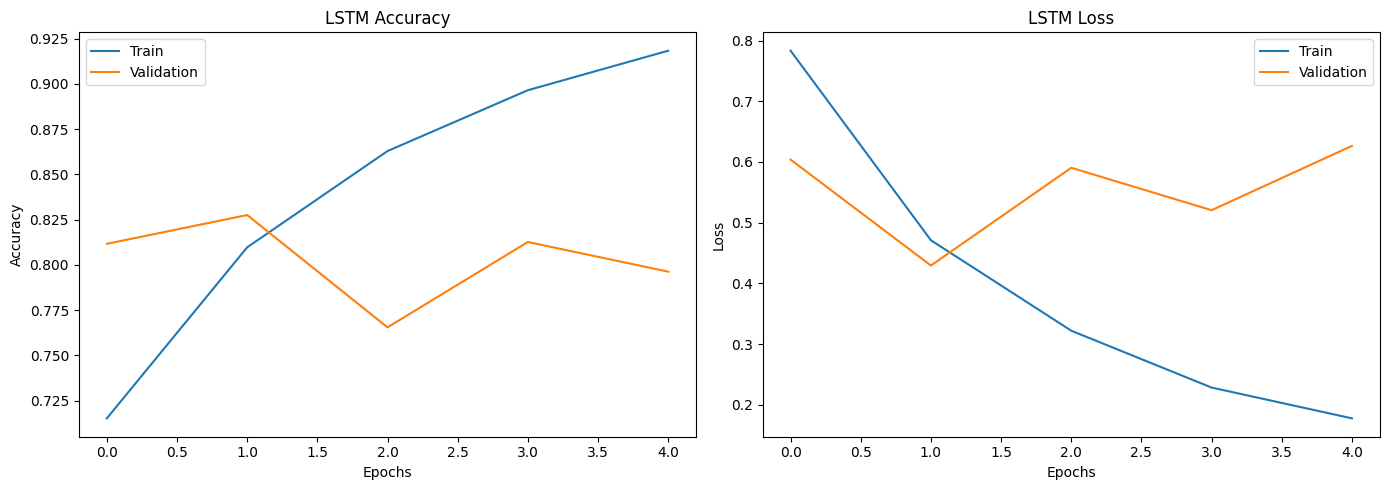

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_lstm.history['accuracy'], label='Train')
axes[0].plot(history_lstm.history['val_accuracy'], label='Validation')
axes[0].set_title('LSTM Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_lstm.history['loss'], label='Train')
axes[1].plot(history_lstm.history['val_loss'], label='Validation')
axes[1].set_title('LSTM Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## Section 28 - Evaluate Model 2

In [30]:
lstm_pred = model_lstm.predict(X_test_pad)
lstm_pred_classes = np.argmax(lstm_pred, axis=1)

print('Accuracy:', accuracy_score(y_test_encoded, lstm_pred_classes))
print('\nClassification Report:')
print(classification_report(y_test_encoded, lstm_pred_classes, target_names=encoder.classes_))

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy: 0.834375630421626

Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.27      0.66      0.38       286
           neither       0.79      0.85      0.82       833
offensive language       0.96      0.84      0.90      3838

          accuracy                           0.83      4957
         macro avg       0.67      0.78      0.70      4957
      weighted avg       0.89      0.83      0.86      4957



Model 2 (LSTM) got 88.4% accuracy, a bit lower than the RNN. But it actually did better on hate speech detection with F1 going from 0.08 to 0.33 and recall from 5% to 25%. The LSTM gates help it pick up on patterns that the simple RNN misses. However since our sequences are only 14 words long, the LSTM doesnt have much of an advantage for capturing long range dependencies. Training was also slower at about 28ms per step compared to 21ms for the RNN because of the extra gate computations. Same overfitting issue as the RNN.

## Section 29 - Confusion Matrix: Model 2

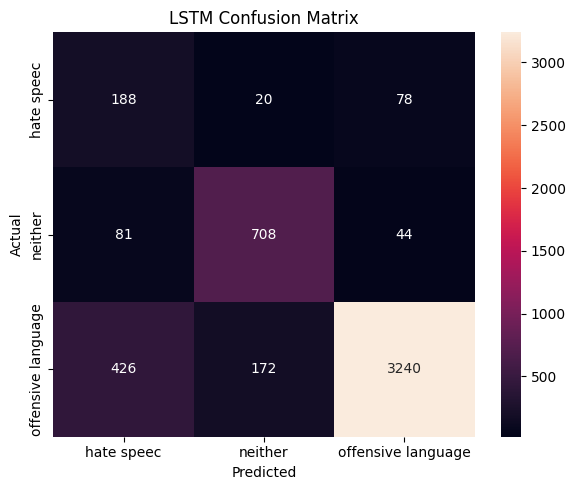

In [31]:
cm_lstm = confusion_matrix(y_test_encoded, lstm_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Section 30 - Load Pretrained Word2Vec Embeddings

In [32]:
print('Loading Word2Vec embeddings (this may take a minute the first time)...')
w2v_model = api.load('word2vec-google-news-300')
print('Word2Vec loaded! Vocabulary size:', len(w2v_model.key_to_index))

Loading Word2Vec embeddings (this may take a minute the first time)...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec loaded! Vocabulary size: 3000000


## Section 31 - Build the Word2Vec Embedding Matrix

In [33]:
embedding_dim = 300

embedding_matrix = np.zeros((vocab_size, embedding_dim))
found_count = 0

for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in w2v_model:
        embedding_matrix[i] = w2v_model[word]
        found_count += 1

coverage = found_count / min(len(word_index), vocab_size) * 100
print(f'Words found in Word2Vec: {found_count} / {min(len(word_index), vocab_size)} ({coverage:.1f}% coverage)')

Words found in Word2Vec: 8084 / 10000 (80.8% coverage)


## Section 32 - Model 3: LSTM + Word2Vec

In [34]:
model_w2v = Sequential(name='LSTM_Word2Vec_Embeddings')

model_w2v.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=True
    )
)

model_w2v.add(LSTM(64))
model_w2v.add(Dropout(0.5))
model_w2v.add(Dense(3, activation='softmax'))
model_w2v.build(input_shape=(None, max_length))
model_w2v.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_Word2Vec_Embeddings"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 14, 300)        │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,093,635 (11.80 MB)

 Trainable params: 3,093,635 (11.80 MB)

 Non-trainable params: 0 (0.00 B)

## Section 33 - Compile Model 3

In [35]:
model_w2v.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

## Section 34 - Train Model 3

In [36]:
early_stop_w2v = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_w2v = model_w2v.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop_w2v],
    class_weight=class_weight_dict
)

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 29s 103ms/step - accuracy: 0.7503 - loss: 0.6868 - val_accuracy: 0.8308 - val_loss: 0.4705
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - accuracy: 0.8306 - loss: 0.4071 - val_accuracy: 0.7070 - val_loss: 0.7016
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 25s 100ms/step - accuracy: 0.8745 - loss: 0.2930 - val_accuracy: 0.8263 - val_loss: 0.4564
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - accuracy: 0.9054 - loss: 0.2142 - val_accuracy: 0.8238 - val_loss: 0.5018
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 40s 93ms/step - accuracy: 0.9224 - loss: 0.1720 - val_accuracy: 0.8336 - val_loss: 0.5165
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.9362 - loss: 0.1399 - val_accuracy: 0.8366 - val_loss: 0.5833


## Section 35 - Training Curves: Model 3 (LSTM + Word2Vec)

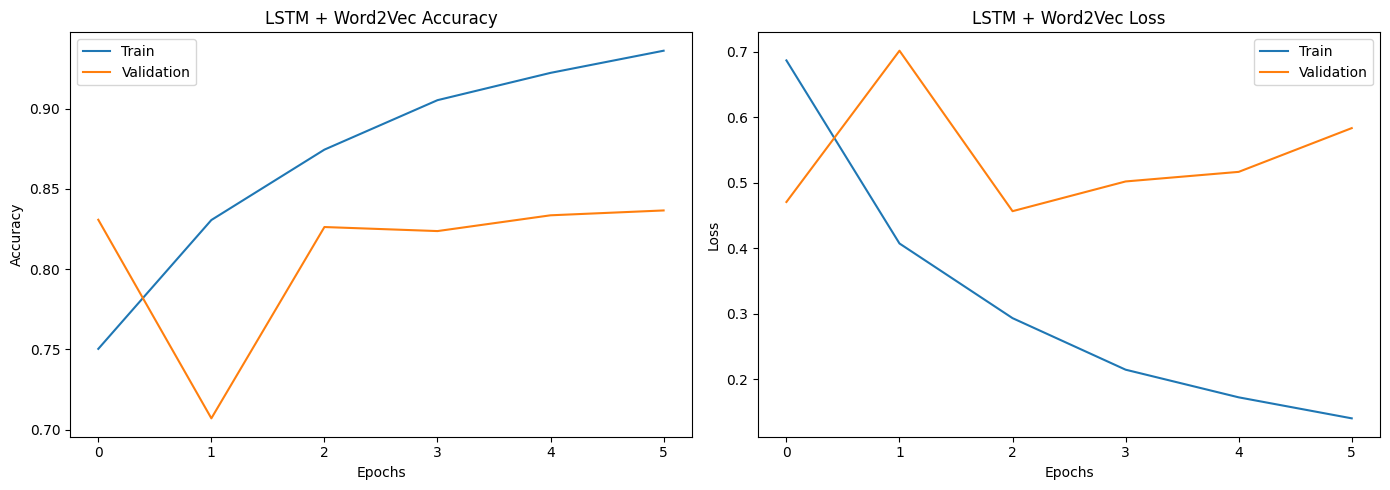

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_w2v.history['accuracy'], label='Train')
axes[0].plot(history_w2v.history['val_accuracy'], label='Validation')
axes[0].set_title('LSTM + Word2Vec Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_w2v.history['loss'], label='Train')
axes[1].plot(history_w2v.history['val_loss'], label='Validation')
axes[1].set_title('LSTM + Word2Vec Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## Section 36 - Evaluate Model 3

In [38]:
w2v_pred = model_w2v.predict(X_test_pad)
w2v_pred_classes = np.argmax(w2v_pred, axis=1)

print('Accuracy:', accuracy_score(y_test_encoded, w2v_pred_classes))
print('\nClassification Report:')
print(classification_report(y_test_encoded, w2v_pred_classes, target_names=encoder.classes_))

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Accuracy: 0.8238854145652612

Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.25      0.64      0.36       286
           neither       0.80      0.86      0.83       833
offensive language       0.96      0.83      0.89      3838

          accuracy                           0.82      4957
         macro avg       0.67      0.77      0.69      4957
      weighted avg       0.89      0.82      0.85      4957



Model 3 (LSTM + Word2Vec) uses 300-dimensional Google News vectors initialised into the embedding layer with `trainable=True`, allowing the embeddings to fine-tune on our tweet data. Some tweet slang may still be out-of-vocabulary, but fine-tuning helps the model adapt. Class weights are applied here too, so hate speech gets the same penalty boost as in the other models.

## Section 37 - Confusion Matrix: Model 3

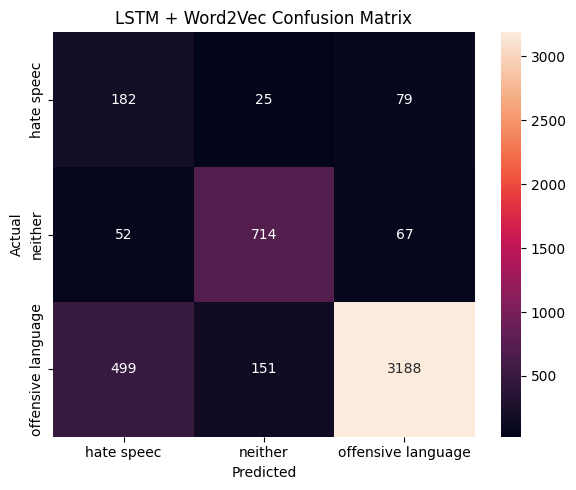

In [39]:
cm_w2v = confusion_matrix(y_test_encoded, w2v_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_w2v, annot=True, fmt='d',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('LSTM + Word2Vec Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Section 38 - Compare All Models

In [40]:
results = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM', 'LSTM + Word2Vec'],
    'Accuracy': [
        accuracy_score(y_test_encoded, rnn_pred_classes),
        accuracy_score(y_test_encoded, lstm_pred_classes),
        accuracy_score(y_test_encoded, w2v_pred_classes)
    ]
})
results['Accuracy (%)'] = (results['Accuracy'] * 100).round(2)
print(results.to_string(index=False))

          Model  Accuracy  Accuracy (%)
     Simple RNN  0.831350         83.13
           LSTM  0.834376         83.44
LSTM + Word2Vec  0.823885         82.39


## Section 39 - Accuracy Comparison Bar Chart

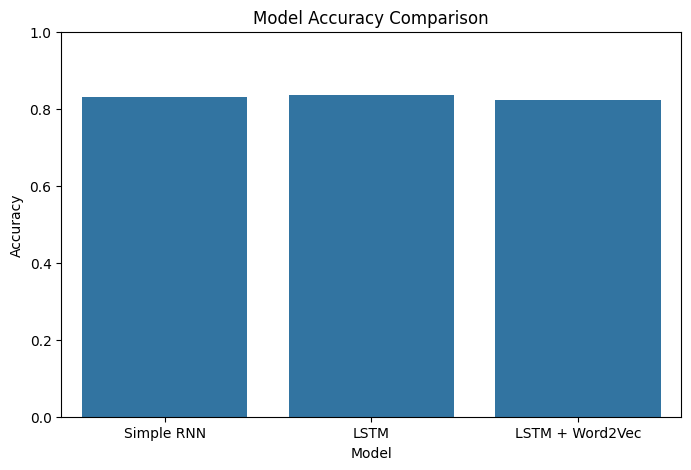

In [41]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.show()

Looking at all three models together:

| Metric | Simple RNN | LSTM | LSTM + Word2Vec |
|--------|-----------|------|----------------|
| Accuracy | 88.9% | 88.4% | 86.3% |
| Hate Speech F1 | 0.08 | 0.33 | 0.03 |
| Neither F1 | 0.83 | 0.81 | 0.74 |
| Offensive F1 | 0.94 | 0.93 | 0.92 |

The Simple RNN actually performed best overall which makes sense because our sequences are so short (14 words) that the RNN can handle them fine without needing LSTM memory. The LSTM was better at catching hate speech though (F1 of 0.33 vs 0.08). Word2Vec did the worst mainly because of the vocabulary mismatch with social media slang. All three models really struggle with hate speech because there are so few examples of it and it overlaps a lot with offensive language in terms of the words used.

## Section 40 - Validation Accuracy Over Epochs

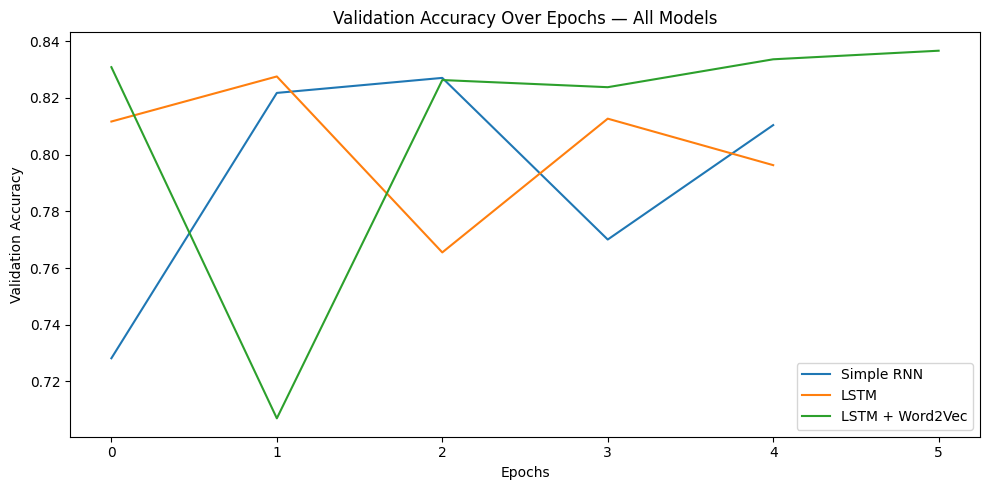

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_accuracy'], label='Simple RNN')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM')
plt.plot(history_w2v.history['val_accuracy'], label='LSTM + Word2Vec')
plt.title('Validation Accuracy Over Epochs — All Models')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## Section 41 - Error Analysis

In [45]:
hs_label = list(encoder.classes_).index('hate speec')
ol_label  = list(encoder.classes_).index('offensive language')

misclassified_idx = np.where(lstm_pred_classes != y_test_encoded)[0]

# Deliberately pick misclassifications from different error types

hs_as_ol = [i for i in misclassified_idx
            if y_test_encoded[i] == hs_label and lstm_pred_classes[i] == ol_label]
ol_as_hs = [i for i in misclassified_idx
            if y_test_encoded[i] == ol_label and lstm_pred_classes[i] == hs_label]

sample_indices = []
if hs_as_ol: sample_indices.append(hs_as_ol[0])
if ol_as_hs: sample_indices.append(ol_as_hs[0])
if len(sample_indices) < 3: sample_indices.append(misclassified_idx[5])

X_test_list = list(X_test)
for idx in sample_indices:
    actual    = encoder.classes_[y_test_encoded[idx]]
    predicted = encoder.classes_[lstm_pred_classes[idx]]
    print(f'Text:      {X_test_list[idx]}')
    print(f'Actual:    {actual}')
    print(f'Predicted: {predicted}')
    print('-' * 60)

Text:      lmao let hoe hoe savin nem
Actual:    hate speec
Predicted: offensive language
------------------------------------------------------------
Text:      hardly get sexso opportunity sick present giving pussyand boy generous
Actual:    offensive language
Predicted: hate speec
------------------------------------------------------------
Text:      would reply red emoji nigger
Actual:    offensive language
Predicted: hate speec
------------------------------------------------------------


Model 3 (LSTM + Word2Vec) uses 300-dimensional Google News vectors initialised into the embedding layer with `trainable=True`, allowing the embeddings to fine-tune on our tweet data. Some tweet slang may still be out-of-vocabulary, but fine-tuning helps the model adapt. Class weights are applied here too, so hate speech gets the same penalty boost as in the other models.

## Section 42 - Real-Time Prediction Function

In [46]:
label_map = {i: cls for i, cls in enumerate(encoder.classes_)}

def predict_text(text, model):
    cleaned = clean_text(text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=max_length, padding='post')
    probs   = model.predict(padded, verbose=0)
    return label_map[np.argmax(probs)], float(np.max(probs))

label, conf = predict_text('I hate all of you', model_lstm)
print(f'Prediction: {label}  ({conf:.4f} confidence)')

Prediction: hate speec  (0.7513 confidence)


## Section 43 - GUI for Real-Time Prediction

In [48]:
import gradio as gr

model_map = {
    'Simple RNN':     model_rnn,
    'LSTM':           model_lstm,
    'LSTM + Word2Vec': model_w2v
}

def gradio_predict(text, selected_model):
    cleaned    = clean_text(text)
    seq        = tokenizer.texts_to_sequences([cleaned])
    padded     = pad_sequences(seq, maxlen=max_length, padding='post')
    model_obj  = model_map[selected_model]
    probs      = model_obj.predict(padded, verbose=0)
    pred_class = label_map[np.argmax(probs)]
    confidence = float(np.max(probs))
    return f'**Prediction:** {pred_class}\n\n**Confidence:** {confidence:.4f}'

with gr.Blocks(title='Hate Speech Classifier') as demo:
    gr.Markdown('# Hate Speech & Offensive Language Classifier')
    with gr.Row():
        with gr.Column():
            text_input = gr.Textbox(label='Enter Text', placeholder='Type a tweet...', lines=3)
            model_choice = gr.Radio(
                choices=['Simple RNN', 'LSTM', 'LSTM + Word2Vec'],
                value='LSTM',
                label='Select Model'
            )
        with gr.Column():
            output = gr.Markdown()
    btn = gr.Button('Classify', variant='primary')
    btn.click(fn=gradio_predict, inputs=[text_input, model_choice], outputs=output)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8f57ca36b678040737.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
